# Predictor layers

In this notebook, we prepare the layers of the predictors later used for Random Forest modeling of post-fire vegetation recovery. We load the data, process it if necessary, and align it with the study area grid created in a previous notebook.

We include the following predictors:
- the 2-month and 2-year median [pre-fire EVI](#Pre-fire-EVI)
- the fire history

## Preparation

In [25]:
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
from rasterio.enums import Resampling
from rasterio import features
import numpy as np

In [2]:
from custom_functions import sel_bounds

In [3]:
study_area = rxr.open_rasterio('output-data/study-area/study_area_kalimantan.tif')

## Pre-fire EVI

We used both a 2-month and 2-year pre-fire median EVI, to capture both an immediate snapshot of vegetation just before the fire as well as a longer-term indicator of vegetation at any given place.

The two datasets were obtained via Google Earth Engine (corresponding scripts can be found in repository), using Landsat 8 data (30m resolution)

In [15]:
# build virtual rasters
!gdalbuildvrt input-data/EVI/Landsat_MedianEVI_Jun_Jul.vrt $(find input-data/EVI -name "Landsat_MedianEVI_Jun_Jul*.tif")
!gdalbuildvrt input-data/EVI/Landsat_MedianEVI_2013_2015.vrt $(find input-data/EVI -name "Landsat_MedianEVI_2012_2015*.tif")

# get all relevant filepaths
# files_2month = sorted(glob.glob("input-data/EVI/Landsat_MedianEVI_Jun_Jul*.tif"))
# files_2year = sorted(glob.glob("input-data/EVI/Landsat_MedianEVI_2012_2015*.tif"))

# load tiles together
evi_2year = xr.open_mfdataset(files_2year, chunks={"x": 1024, "y": 1024}).rename({'band_data': 'EVI_2year_pre'})
evi_2month = xr.open_mfdataset(files_2month, chunks={"x": 1024, "y": 1024}).rename({'band_data': 'EVI_2month_pre'})

# combine in one dataset (since grids already align)
evi_pre = evi_2year.merge(evi_2month, compat='no_conflicts')

# crop to study area
evi_pre_kalimantan = sel_bounds(evi_pre, study_area)

In [18]:
# reproject to match study area raster -> this will be the xarray dataset where we collect all predictor layers
predictor_stack = evi_pre_kalimantan.rio.reproject_match(
    study_area, 
    resampling=Resampling.average) # coarsen (30m to 250m), therefore take mean

In [23]:
# save
evi_pre_kalimantan_reproj.EVI_2month_pre.rio.to_raster('output-data/predictor-layers/evi_2month_pre.tif')
evi_pre_kalimantan_reproj.EVI_2year_pre.rio.to_raster('output-data/predictor-layers/evi_2year_pre.tif')

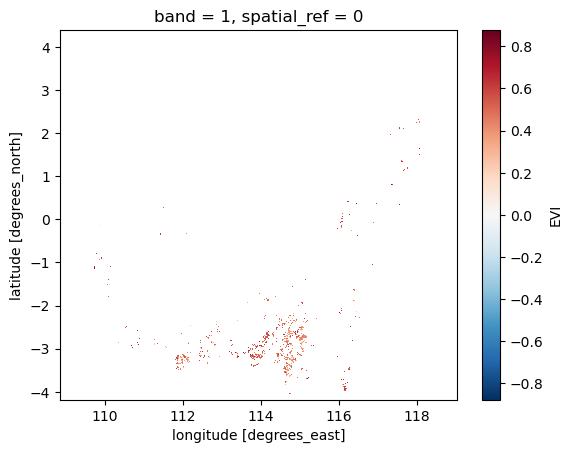

In [20]:
evi_pre_kalimantan_reproj.EVI_2month_pre.plot()

## Fire history

This layer indicates fire frequency, measured as the total number of fires in a given pixel between 2001 (start of the MODIS fire alerts dataset) and July 2015 (before our fire season).

For this purpose, we only used fire alerts with confidence > 70%, as defined in the first notebook.

In [11]:
# load fire alert points until July 2015 (created and exported in 1_study_area.ipynb)
fires_before = gpd.read_file('output-data/fire-alerts/fire_alerts_before.shp')

In [27]:
from rasterio import features
from rasterio.enums import MergeAlg
import numpy as np

# project to metric CRS
fires_proj = fires_before.to_crs("EPSG:3857")

# buffer 500 m
fires_proj["geometry"] = fires_proj.buffer(500, cap_style='square')

# back to study CRS
fires_buffered = fires_proj.to_crs(predictor_stack.rio.crs)

transform = study_area.rio.transform()
out_shape = study_area.rio.shape

# rasterize all at once and SUM overlaps
fire_count_array = features.rasterize(
    ((geom, 1) for geom in fires_buffered.geometry),
    out_shape=out_shape,
    transform=transform,
    all_touched=True, # any time pixel is touched by a buffer count as burn
    merge_alg=MergeAlg.add,
    dtype="uint16"
)

In [31]:
# add to merged stack
predictor_stack["prev_fire_count"] = xr.DataArray(
    fire_count_array,
    dims=["y", "x"],
    coords={"y": predictor_stack.y, "x": predictor_stack.x},
)


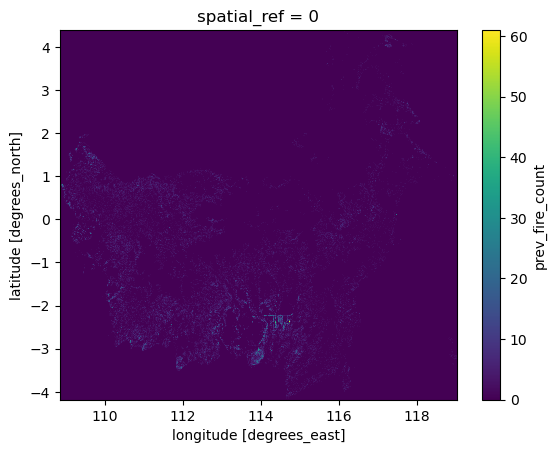

In [32]:
predictor_stack.prev_fire_count.plot()

## Distance to intact forest

## Distance to drainage channels

In [33]:
# load data 

# build virtual raster
!gdalbuildvrt input-data/drainage-canals/drainage_canals.vrt $(find input-data/drainage-canals -name "*.tif")

# load                                                                   
drainage_complete = rxr.open_rasterio('input-data/drainage-canals/drainage_canals.vrt')

0...10...20...30...40...50...60...70...80...90...100 - done.


In [45]:
drainage_complete.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]')

In [44]:
drainage_complete.rio.resolution()

(4.777314267160143, -4.777314267160143)

## Final

In [ ]:
# set all values outside study area to NaN

#ds = ds.where(ds['study_area'] == 1)
